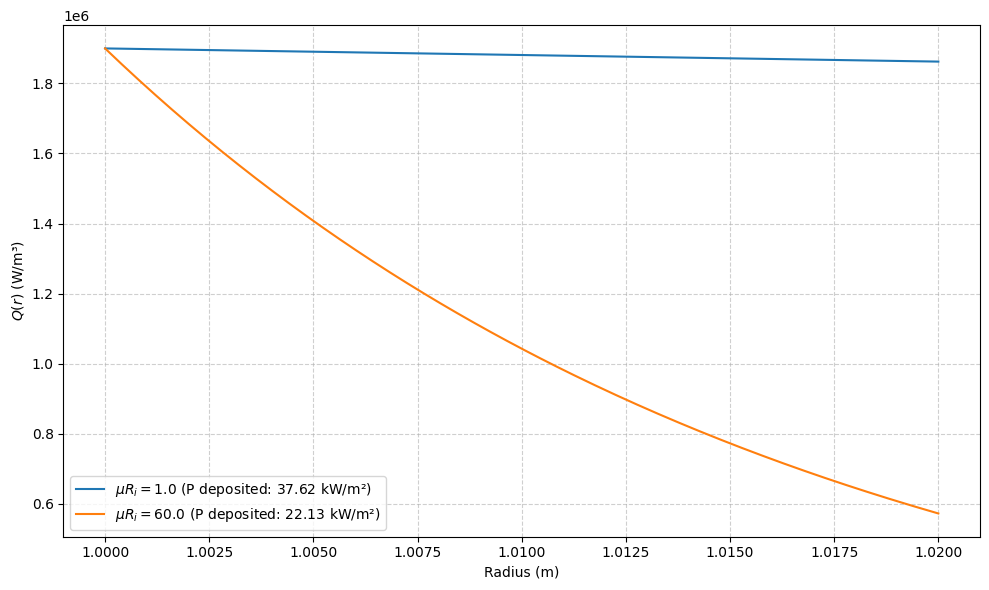

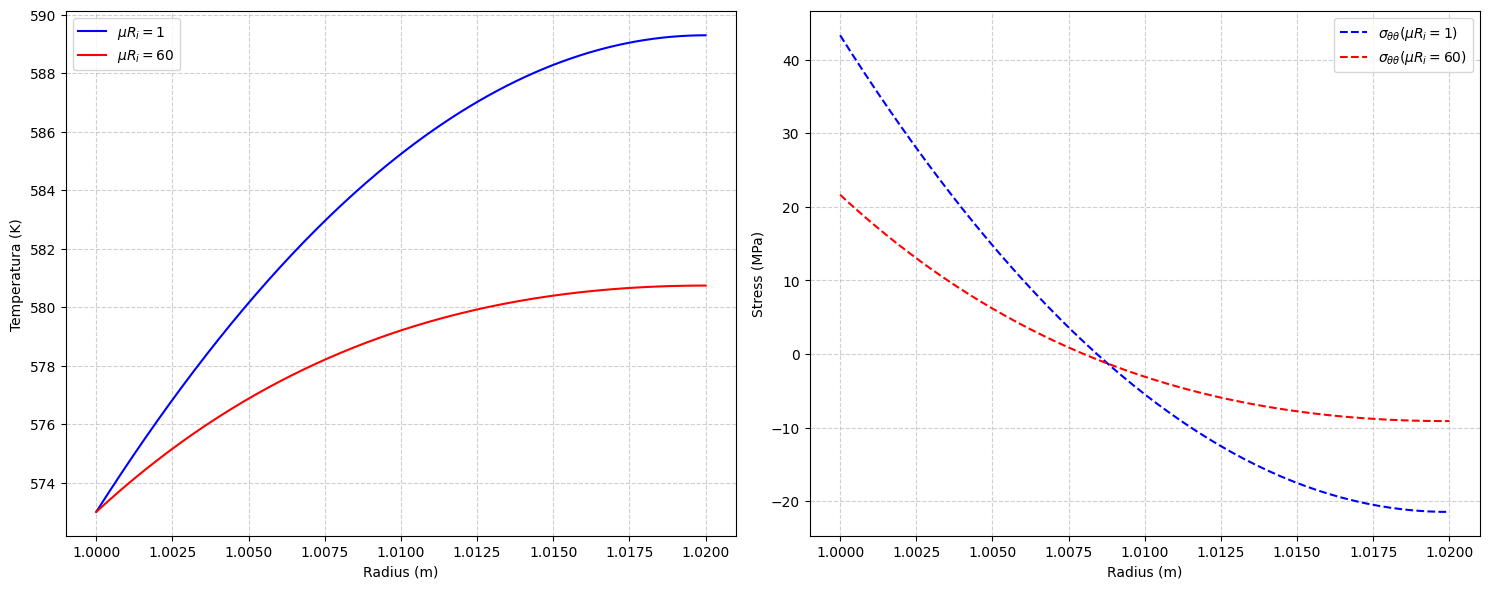

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Ri = 1.0        # m
Ro = 1.02       # m
Lx = Ro - Ri    # m
Ti = 573.0      # K
E = 1.5e11      # Pa
nu = 0.32       # -
alpha = 1.8e-5  # 1/K
k = 23.0        # W/(m K)
q0 = 1.9e6      # W/m3

# --.. ..- .-.. .-.. --- analytic functions  --.. ..- .-.. .-.. ---
def analytic_T(r, mu):
    """Analytical temperature profile (slab approx), Dirichlet-Neumann."""
    x = r - Ri
    return Ti + q0 / (k * mu**2) * (1 - np.exp(-mu * x) - mu * x * np.exp(-mu * Lx))

def analytical_thermal_stress(r, mu):
    """Analytical thermal stresses in a cylinder for arbitrary T(r)."""
    r_star = np.linspace(Ri, Ro, 20000)
    T_star = analytic_T(r_star, mu)

    I_global = np.trapezoid(T_star * r_star, r_star)
    
    sigma_r, sigma_t, sigma_z = np.zeros_like(r), np.zeros_like(r), np.zeros_like(r)

    for i, ri in enumerate(r):
        mask = r_star <= ri
        I_local = np.trapezoid(T_star[mask] * r_star[mask], r_star[mask])
        
        factor = (alpha * E / (1 - nu))
        
        sigma_r[i] = factor * (1 / ri**2) * (((ri**2 - Ri**2) / (Ro**2 - Ri**2)) * I_global - I_local)
        sigma_t[i] = factor * (((1 + (Ri / ri)**2) / (Ro**2 - Ri**2)) * I_global + I_local / ri**2 - analytic_T(ri, mu))
        sigma_z[i] = factor * ((2 / (Ro**2 - Ri**2)) * I_global - analytic_T(ri, mu))

    return sigma_r, sigma_t, sigma_z

r_plot = np.linspace(Ri, Ro, 200)

# mu*Ri = 1 vs mu*Ri = 60
mu_vals = [1.0, 60.0]
results = {}

plt.figure(figsize=(10, 6))

for m_ri in mu_vals:
    mu = m_ri / Ri
    T = analytic_T(r_plot, mu)
    sr, st, sz = analytical_thermal_stress(r_plot, mu)
    results[m_ri] = {'T': T, 'st': st}
    Q = q0 * np.exp(-mu * (r_plot - Ri))
    
    P_total = np.trapezoid(Q, r_plot)
    plt.plot(r_plot, Q, label=f'$\\mu R_i = {m_ri}$ (P deposited: {P_total/1000:.2f} kW/m²)')

plt.xlabel("Radius (m)")
plt.ylabel("$Q(r)$ (W/m³)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Display
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
Pa_to_MPa = 1e-6

ax[0].plot(r_plot, results[1.0]['T'], 'b-', label=r'$\mu R_i = 1$')
ax[0].plot(r_plot, results[60.0]['T'], 'r-', label=r'$\mu R_i = 60$')
ax[0].set_xlabel("Radius (m)")
ax[0].set_ylabel("Temperatura (K)")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].plot(r_plot, results[1.0]['st'] * Pa_to_MPa, 'b--', label=r'$\sigma_{\theta \theta} (\mu R_i=1)$')
ax[1].plot(r_plot, results[60.0]['st'] * Pa_to_MPa, 'r--', label=r'$\sigma_{\theta \theta} (\mu R_i=60)$')
ax[1].set_xlabel("Radius (m)")
ax[1].set_ylabel("Stress (MPa)")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()